# Car Price Prediction with Machine Learning

## OASIS INFOBYTE Data Analytics Internship — Task 3

### Objective

The objective of this project is to develop a machine learning regression model to predict the selling price of used cars.

The analysis uses important vehicle attributes such as manufacturing year, kilometres driven, fuel type, seller type, transmission, owner type, and car brand.

The project follows a complete machine learning workflow including:

- Data loading and exploration
- Data cleaning
- Duplicate removal
- Feature engineering
- Exploratory Data Analysis (EDA)
- Categorical variable encoding
- Train-test splitting
- Regression model development
- Model evaluation
- Feature importance analysis
- Prediction and residual analysis

Three regression models are implemented and compared:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The models are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab
- Jupyter Notebook

### Machine Learning Algorithms

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

### Evaluation Metrics

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv('/content/CAR DETAILS FROM CAR DEKHO.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (4340, 8)


Observation:
The CarDekho used-car dataset was successfully loaded. The dataset contains 4,340 records and 8 columns.

In [ ]:

# Display the first 5 rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


Observation:
The dataset contains information about used cars, including car name, manufacturing year, selling price, kilometres driven, fuel type, seller type, transmission and owner.

In [ ]:

# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


Observation:
The dataset contains both numerical and categorical variables. The numerical variables include year, selling price and kilometres driven, while the remaining variables are categorical.

In [ ]:

# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


Observation:
There are no missing values in any of the columns. Therefore, no missing-value treatment is required.

In [ ]:

# Check for duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 763


Observation:
The dataset contains 763 duplicate records. These duplicate records should be removed before further analysis and machine learning.

In [ ]:

# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (3577, 8)


Observation:
After removing duplicate records, the dataset contains 3,577 unique records and 8 columns. This cleaned dataset will be used for further analysis.

In [ ]:

# Check unique values in categorical columns

categorical_columns = ['fuel', 'seller_type', 'transmission', 'owner']

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


fuel:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

seller_type:
['Individual' 'Dealer' 'Trustmark Dealer']

transmission:
['Manual' 'Automatic']

owner:
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


Observation:
The categorical variables contain clearly defined categories. Fuel type includes Petrol, Diesel, CNG, LPG and Electric. Transmission includes Manual and Automatic, while seller type and owner also contain multiple categories.

In [ ]:

# Feature Engineering

# Extract car brand from car name
df['brand'] = df['name'].str.split().str[0]

# Calculate car age
reference_year = df['year'].max()
df['car_age'] = reference_year - df['year']

# Display the newly created features
df[['name', 'year', 'brand', 'car_age']].head()

,name,year,brand,car_age
0,Maruti 800 AC,2007,Maruti,13
1,Maruti Wagon R LXI Minor,2007,Maruti,13
2,Hyundai Verna 1.6 SX,2012,Hyundai,8
3,Datsun RediGO T Option,2017,Datsun,3
4,Honda Amaze VX i-DTEC,2014,Honda,6


Observation:
Two new features were created. The brand was extracted from the car name, and car age was calculated using the manufacturing year. These features can help explain variations in used-car selling prices.

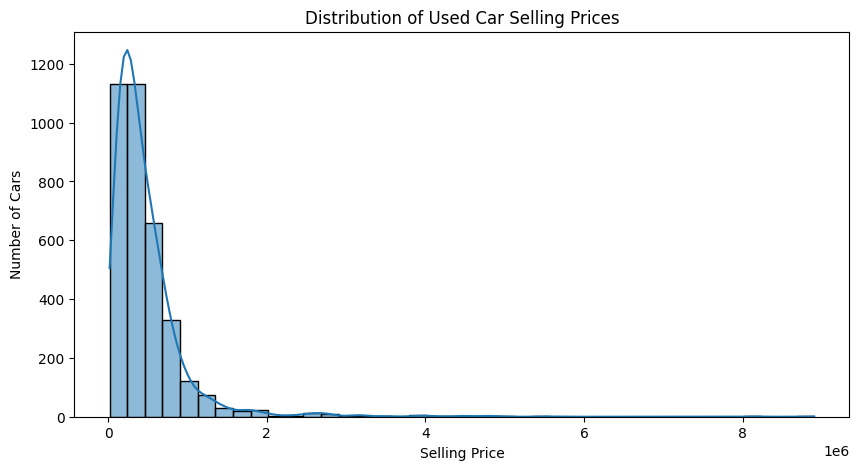

In [ ]:

# Distribution of selling price

plt.figure(figsize=(10, 5))
sns.histplot(df['selling_price'], bins=40, kde=True)

plt.title('Distribution of Used Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

Observation:
The histogram shows the distribution of used-car selling prices. Most cars are concentrated in the lower and middle price ranges, while relatively fewer cars have very high selling prices.

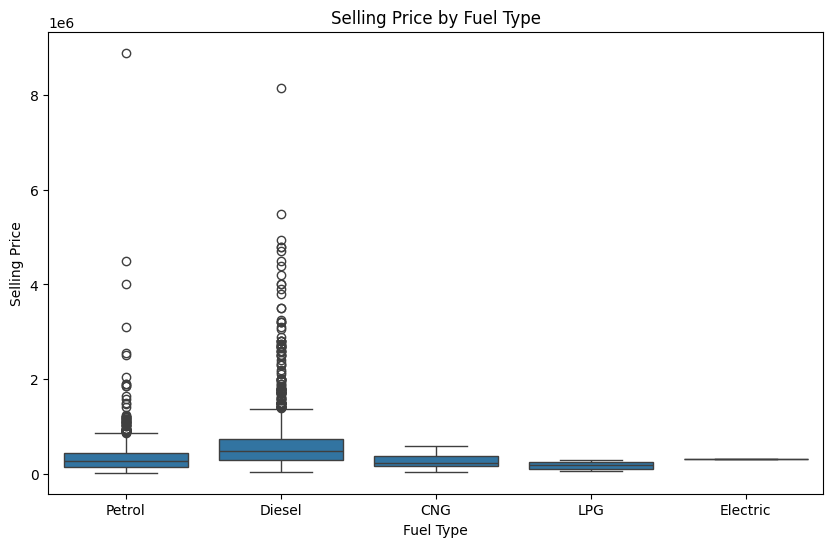

In [ ]:

# Selling price by fuel type

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='fuel', y='selling_price')

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')

plt.show()

Observation:
The box plot compares selling-price distributions across different fuel types. It helps identify differences in price levels, spread and potential outliers among fuel categories.

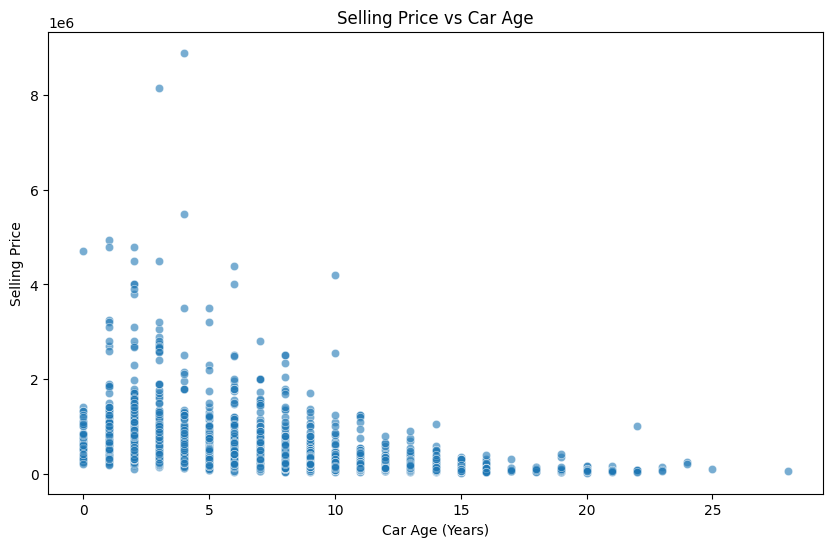

In [ ]:

# Selling Price vs Car Age

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='car_age', y='selling_price', alpha=0.6)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')

plt.show()

Observation:
The scatter plot shows the relationship between car age and selling price. In general, newer cars tend to have higher selling prices, while older cars tend to have lower prices, although other factors also influence the selling price.

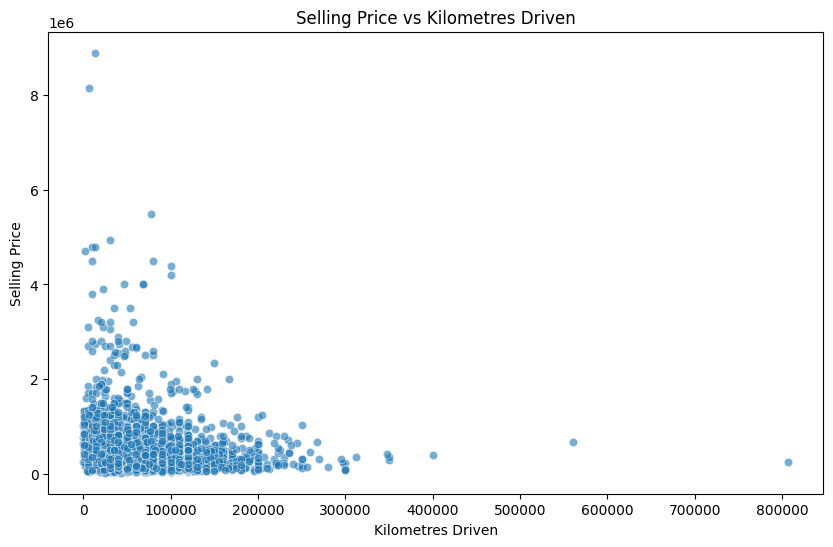

In [ ]:

# Selling Price vs Kilometres Driven

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='km_driven', y='selling_price', alpha=0.6)

plt.title('Selling Price vs Kilometres Driven')
plt.xlabel('Kilometres Driven')
plt.ylabel('Selling Price')

plt.show()

Observation:
The scatter plot shows the relationship between kilometres driven and selling price. Cars with higher mileage generally tend to have lower selling prices, although the relationship is affected by other car characteristics.

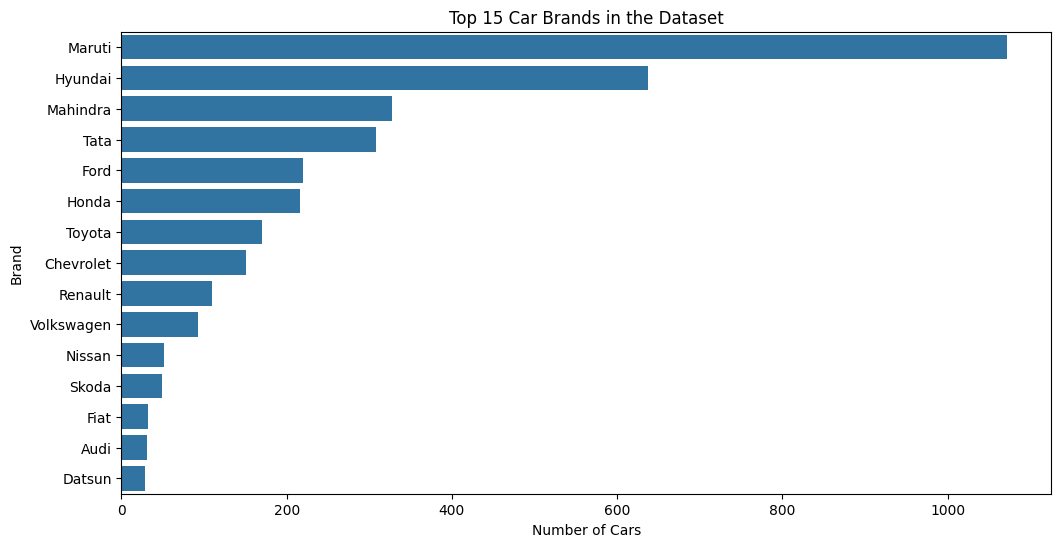

In [ ]:

# Top 15 car brands by number of cars

top_brands = df['brand'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_brands.values, y=top_brands.index)

plt.title('Top 15 Car Brands in the Dataset')
plt.xlabel('Number of Cars')
plt.ylabel('Brand')

plt.show()

Observation:
The bar chart shows the 15 most frequently represented car brands in the dataset. The distribution indicates that some brands have considerably more observations than others.

transmission
Automatic    1.274955e+06
Manual       3.973657e+05
Name: selling_price, dtype: float64


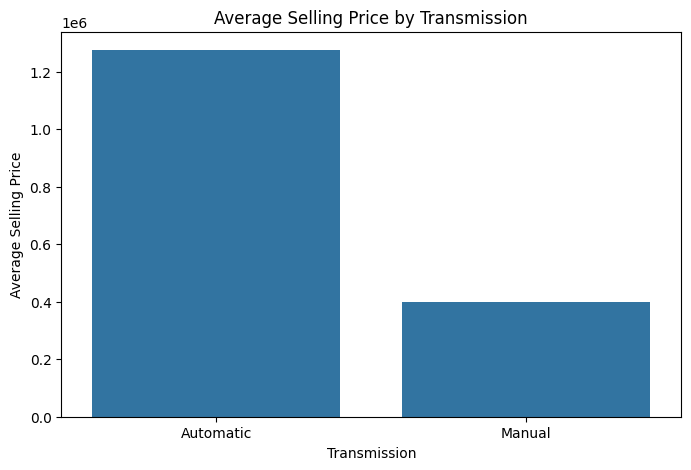

In [ ]:

# Average selling price by transmission

transmission_price = df.groupby('transmission')['selling_price'].mean().sort_values(ascending=False)

print(transmission_price)

plt.figure(figsize=(8, 5))
sns.barplot(x=transmission_price.index, y=transmission_price.values)

plt.title('Average Selling Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Average Selling Price')

plt.show()

Observation:
The average selling price differs between manual and automatic cars. This indicates that transmission type may be an important feature for predicting used-car selling prices.

fuel
Diesel      614001.075000
Petrol      335344.340128
Electric    310000.000000
CNG         273162.081081
LPG         171818.136364
Name: selling_price, dtype: float64


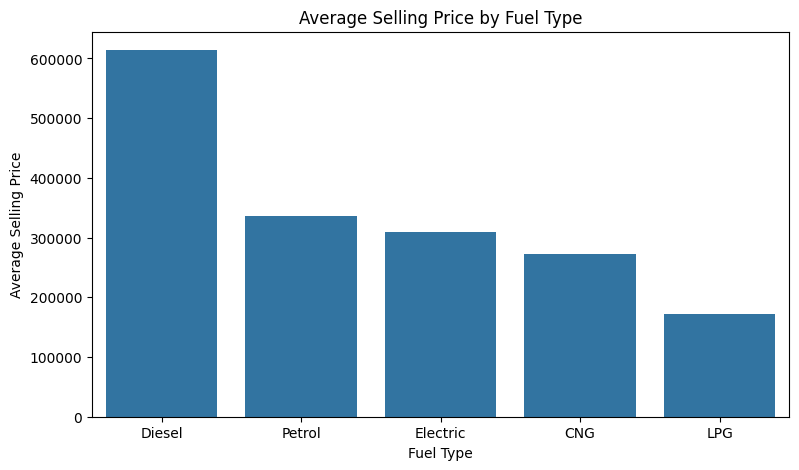

In [ ]:

# Average selling price by fuel type

fuel_price = df.groupby('fuel')['selling_price'].mean().sort_values(ascending=False)

print(fuel_price)

plt.figure(figsize=(9, 5))
sns.barplot(x=fuel_price.index, y=fuel_price.values)

plt.title('Average Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Selling Price')

plt.show()

Observation:
The average selling price varies across fuel types. This suggests that fuel type may contribute to differences in used-car prices.

In [ ]:

# Statistical summary of numerical features

df[['year', 'selling_price', 'km_driven', 'car_age']].describe()

,year,selling_price,km_driven,car_age
count,3577.000000,3.577000e+03,3577.000000,3577.000000
mean,2012.962538,4.739125e+05,69250.545709,7.037462
std,4.251759,5.093018e+05,47579.940016,4.251759
min,1992.000000,2.000000e+04,1.000000,0.000000
25%,2010.000000,2.000000e+05,36000.000000,4.000000
50%,2013.000000,3.500000e+05,60000.000000,7.000000
75%,2016.000000,6.000000e+05,90000.000000,10.000000
max,2020.000000,8.900000e+06,806599.000000,28.000000


Observation:
The statistical summary provides information about the count, mean, standard deviation, minimum, maximum and quartile values of the numerical features. It helps understand the scale and spread of the dataset.

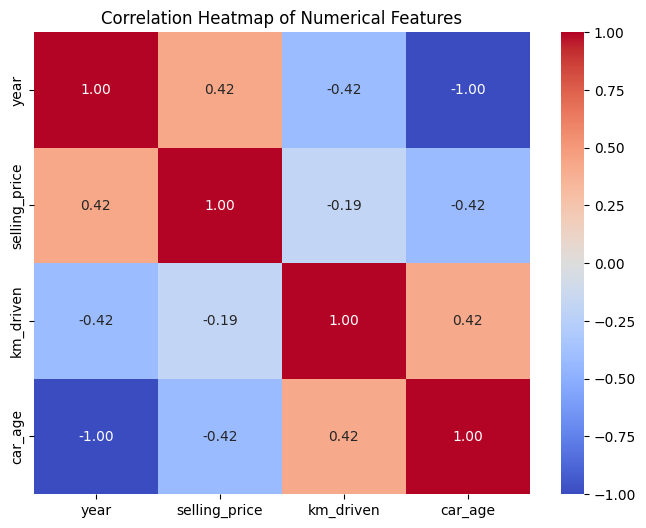

In [ ]:

# Correlation matrix for numerical features

numerical_features = ['year', 'selling_price', 'km_driven', 'car_age']

correlation_matrix = df[numerical_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Numerical Features')

plt.show()

Observation:
The correlation heatmap shows the strength and direction of relationships between numerical features. It helps identify which numerical variables may have stronger relationships with selling price and with each other.

In [ ]:

# Select features and target variable

features = [
    'year',
    'km_driven',
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand',
    'car_age'
]

X = df[features].copy()
y = df['selling_price'].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("selling_price")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'brand', 'car_age']

Target:
selling_price

Feature shape: (3577, 8)
Target shape: (3577,)


Observation:
The independent variables have been selected as model features, while selling_price is selected as the target variable. The model will learn the relationship between these features and the selling price.

In [ ]:

# Encode categorical variables using LabelEncoder

categorical_features = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand'
]

label_encoders = {}

for column in categorical_features:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])
    label_encoders[column] = encoder

print("Categorical variables encoded successfully!")
X.head()

Categorical variables encoded successfully!


,year,km_driven,fuel,seller_type,transmission,owner,brand,car_age
0,2007,70000,4,1,1,0,18,13
1,2007,50000,4,1,1,0,18,13
2,2012,100000,1,1,1,0,10,8
3,2017,46000,4,1,1,0,5,3
4,2014,141000,1,1,1,2,9,6


Observation:
The categorical variables have been converted into numerical values so that machine-learning regression algorithms can process them.

In [ ]:

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (2861, 8)
Testing features: (716, 8)
Training target: (2861,)
Testing target: (716,)


Observation:
The dataset has been divided into training and testing sets. 80% of the data will be used to train the regression models, while 20% will be used to evaluate their performance on unseen data.

In [ ]:

# Train Linear Regression model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


Observation:
The Linear Regression model was successfully trained using the training dataset. It will be evaluated using the unseen testing data.

In [ ]:

# Evaluate Linear Regression

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Performance
--------------------------------
MAE : 214459.0048810105
RMSE: 444901.4293627095
R²  : 0.38554241873749917


Observation:
The Linear Regression model has been evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score. These metrics measure prediction error and how well the model explains the variation in selling price.

In [ ]:

# Train Random Forest Regressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


Observation:
The Random Forest Regressor was successfully trained. The model combines multiple decision trees to capture non-linear relationships between car characteristics and selling price.

In [ ]:

# Evaluate Random Forest Regressor

rf_mae = mean_absolute_error(y_test, random_forest_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, random_forest_predictions))
rf_r2 = r2_score(y_test, random_forest_predictions)

print("Random Forest Performance")
print("--------------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Performance
--------------------------------
MAE : 169215.36443782243
RMSE: 413217.597751026
R²  : 0.4699437959255277


Observation:
The Random Forest model has been evaluated using MAE, RMSE and R². These results will be compared with Linear Regression and the other regression model.

In [ ]:

# Train Gradient Boosting Regressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

gradient_boosting_predictions = gradient_boosting_model.predict(X_test)

print("Gradient Boosting Regressor trained successfully!")

Gradient Boosting Regressor trained successfully!


Observation:
The Gradient Boosting Regressor was successfully trained. It builds models sequentially to improve prediction performance and capture complex relationships in the data.

In [ ]:

# Evaluate Gradient Boosting Regressor

gb_mae = mean_absolute_error(y_test, gradient_boosting_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gradient_boosting_predictions))
gb_r2 = r2_score(y_test, gradient_boosting_predictions)

print("Gradient Boosting Performance")
print("--------------------------------")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting Performance
--------------------------------
MAE : 162286.3383379227
RMSE: 402660.9344462851
R²  : 0.4966810301848863


Observation:
The Gradient Boosting model has been evaluated using MAE, RMSE and R². Its performance can now be compared with the Linear Regression and Random Forest models.

In [ ]:

# Compare model performance

model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    'R2 Score': [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,214459.004881,444901.429363,0.385542
1,Random Forest,169215.364438,413217.597751,0.469944
2,Gradient Boosting,162286.338338,402660.934446,0.496681


Observation:
The three regression models are compared using MAE, RMSE and R². Lower MAE and RMSE indicate smaller prediction errors, while a higher R² score indicates that the model explains more variation in selling price.

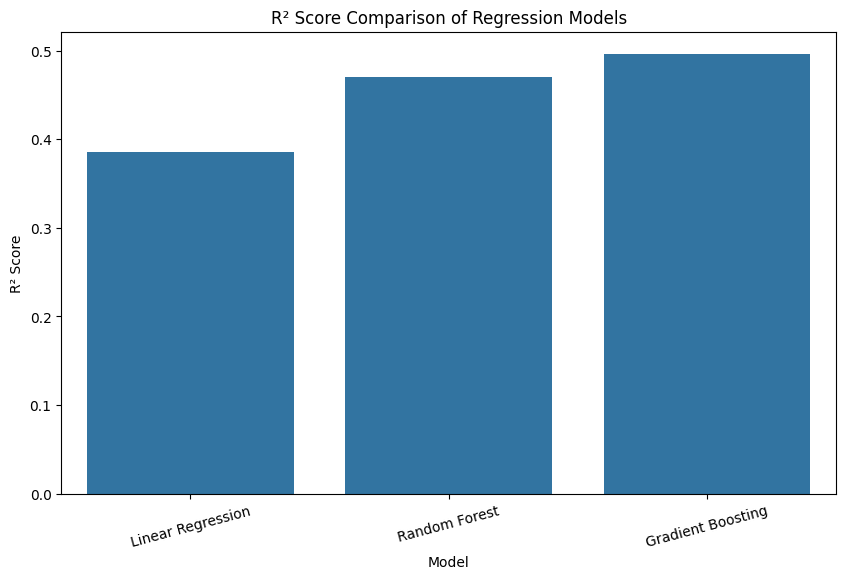

In [ ]:

# Visual comparison of R² scores

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison,
    x='Model',
    y='R2 Score'
)

plt.title('R² Score Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=15)

plt.show()

Observation:
The bar chart provides a visual comparison of the R² scores of the three regression models. The model with the highest R² score provides the strongest explanatory performance among the tested models.

In [ ]:

# Select the best model based on R² score

best_model_name = model_comparison.loc[
    model_comparison['R2 Score'].idxmax(),
    'Model'
]

print("Best Model based on R² Score:", best_model_name)

Best Model based on R² Score: Gradient Boosting


Observation:
The best-performing model is selected based on the highest R² score among the three tested regression models. This model will be used for further analysis and feature-importance visualization.

In [ ]:

# Feature importance of the best model: Gradient Boosting

gb_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gradient_boosting_model.feature_importances_
})

gb_feature_importance = gb_feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(gb_feature_importance)

        Feature  Importance
4  transmission    0.308331
6         brand    0.269421
0          year    0.139836
2          fuel    0.124982
7       car_age    0.105805
1     km_driven    0.045362
3   seller_type    0.004072
5         owner    0.002190


Observation:
The feature-importance values show the relative contribution of each feature to the Gradient Boosting model. Features with higher importance have a greater influence on the predicted selling price.

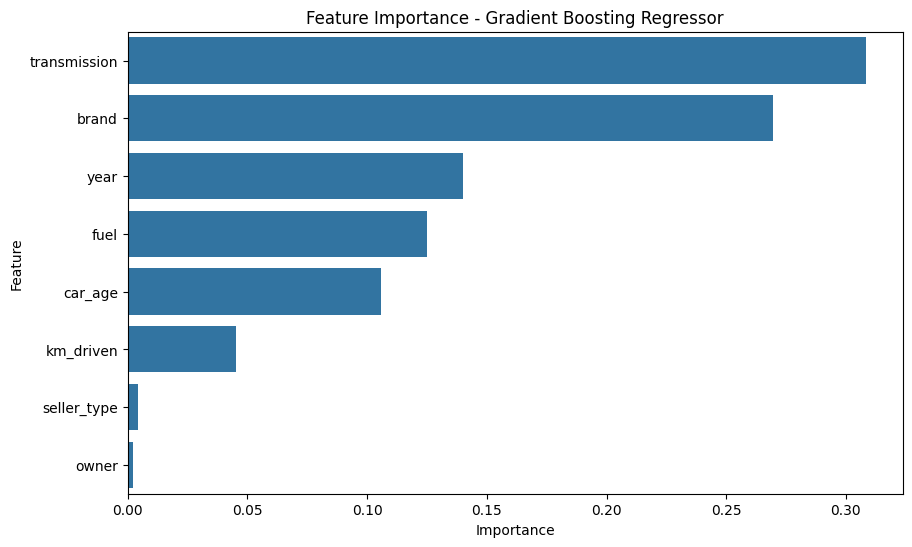

In [ ]:

# Feature importance visualization

plt.figure(figsize=(10, 6))

sns.barplot(
    data=gb_feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Gradient Boosting Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

Observation:
The feature-importance chart visually identifies the features that contribute most to the Gradient Boosting model's predictions. This helps explain which car characteristics are most influential in predicting selling price.

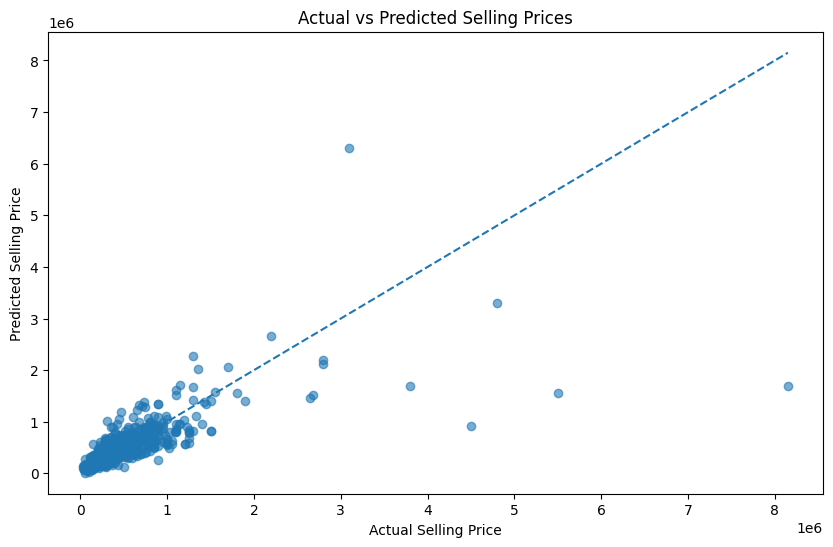

In [ ]:

# Actual vs Predicted Selling Prices

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    gradient_boosting_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title('Actual vs Predicted Selling Prices')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')

plt.show()

Observation:
The actual-versus-predicted plot compares the prices predicted by the Gradient Boosting model with the actual selling prices. Points closer to the diagonal line represent more accurate predictions.

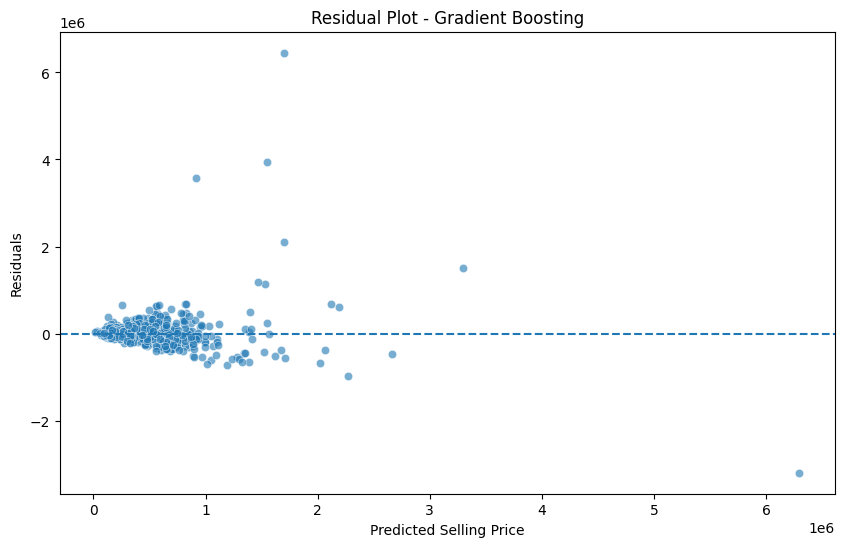

In [ ]:

# Calculate prediction residuals

residuals = y_test - gradient_boosting_predictions

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=gradient_boosting_predictions,
    y=residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title('Residual Plot - Gradient Boosting')
plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals')

plt.show()

Observation:
The residual plot shows the difference between actual and predicted selling prices. Residuals distributed around zero indicate that the model does not consistently overestimate or underestimate prices in one direction.

In [ ]:

# Final performance metrics of the best model

best_mae = mean_absolute_error(
    y_test,
    gradient_boosting_predictions
)

best_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gradient_boosting_predictions
    )
)

best_r2 = r2_score(
    y_test,
    gradient_boosting_predictions
)

print("Best Model: Gradient Boosting Regressor")
print("----------------------------------------")
print(f"MAE  : ₹{best_mae:,.2f}")
print(f"RMSE : ₹{best_rmse:,.2f}")
print(f"R²   : {best_r2:.4f}")

Best Model: Gradient Boosting Regressor
----------------------------------------
MAE  : ₹162,286.34
RMSE : ₹402,660.93
R²   : 0.4967


Observation:
The Gradient Boosting Regressor achieved an MAE of approximately ₹162,286, an RMSE of approximately ₹402,661 and an R² score of approximately 0.497 on the test dataset.

In [ ]:

# Display sample actual and predicted prices

prediction_results = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': gradient_boosting_predictions
})

prediction_results.head(10)

,Actual Price,Predicted Price
0,270000,4.628824e+05
1,525000,4.442232e+05
2,990000,1.105225e+06
3,3800000,1.699387e+06
4,229999,1.709861e+05
5,325000,2.990706e+05
6,210000,1.550659e+05
7,500000,5.648846e+05
8,790000,9.035814e+05
9,360000,3.798509e+05


Observation:
The table compares actual selling prices with prices predicted by the Gradient Boosting model for sample test records. It provides a direct view of the model's prediction performance.

In [ ]:

# Calculate percentage error for sample predictions

sample_results = prediction_results.head(10).copy()

sample_results['Percentage Error'] = (
    abs(
        sample_results['Actual Price'] -
        sample_results['Predicted Price']
    )
    / sample_results['Actual Price']
) * 100

sample_results

,Actual Price,Predicted Price,Percentage Error
0,270000,4.628824e+05,71.437938
1,525000,4.442232e+05,15.386065
2,990000,1.105225e+06,11.638931
3,3800000,1.699387e+06,55.279289
4,229999,1.709861e+05,25.657876
5,325000,2.990706e+05,7.978262
6,210000,1.550659e+05,26.159087
7,500000,5.648846e+05,12.976923
8,790000,9.035814e+05,14.377396
9,360000,3.798509e+05,5.514139


Observation:
The percentage error shows the relative difference between actual and predicted selling prices for the sample records. Lower percentage errors indicate predictions that are closer to the actual prices.

In [ ]:

# Final model performance table

final_results = model_comparison.copy()

final_results['MAE'] = final_results['MAE'].round(2)
final_results['RMSE'] = final_results['RMSE'].round(2)
final_results['R2 Score'] = final_results['R2 Score'].round(4)

final_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,214459.00,444901.43,0.3855
1,Random Forest,169215.36,413217.60,0.4699
2,Gradient Boosting,162286.34,402660.93,0.4967


Observation:
The final performance table summarizes the results of all three regression models. Gradient Boosting achieved the highest R² score and the lowest MAE and RMSE among the tested models.

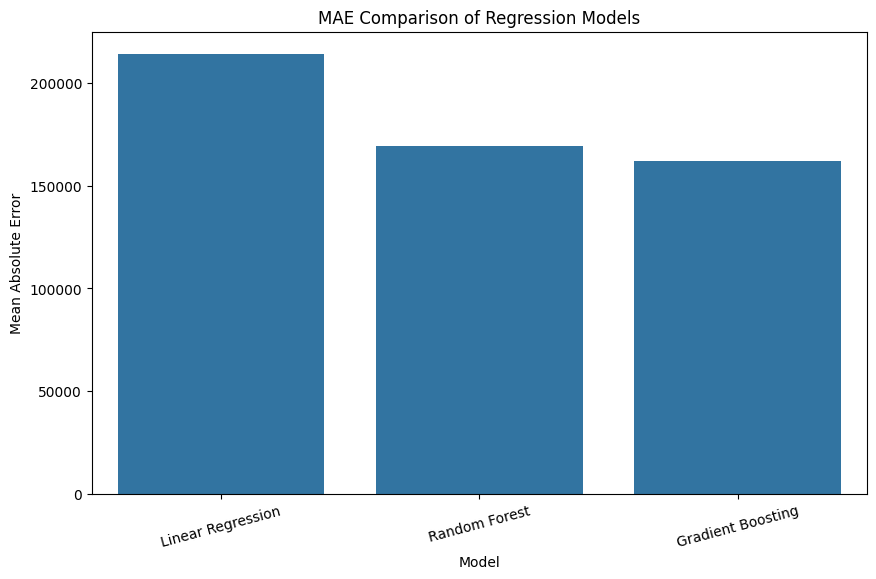

In [ ]:

# Compare MAE of all models

plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_results,
    x='Model',
    y='MAE'
)

plt.title('MAE Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('Mean Absolute Error')
plt.xticks(rotation=15)

plt.show()

Observation:
The MAE comparison shows the average absolute prediction error of each regression model. Gradient Boosting has the lowest MAE among the three tested models.

## Key Findings

- The original dataset contained 4,340 records and 8 columns.
- No missing values were found in the dataset.
- 763 duplicate records were identified and removed.
- After duplicate removal, 3,577 records remained for analysis.
- Car brand was extracted from the car name as a new feature.
- Car age was calculated from the manufacturing year.
- Three regression models were trained and evaluated.
- Gradient Boosting Regressor achieved the highest R² score among the tested models.
- Gradient Boosting Regressor also produced the lowest MAE and RMSE among the tested models.
- In the Gradient Boosting model, transmission, brand, year, fuel type, and car age had relatively higher feature-importance values.

In [ ]:

# Final project conclusion

print("FINAL PROJECT CONCLUSION")
print("=" * 50)
print("Dataset: CarDekho Used Car Dataset")
print("Records after cleaning:", len(df))
print("Models tested: Linear Regression, Random Forest, Gradient Boosting")
print("Best Model: Gradient Boosting Regressor")
print(f"Best Model R² Score: {best_r2:.4f}")
print(f"Best Model MAE: ₹{best_mae:,.2f}")
print(f"Best Model RMSE: ₹{best_rmse:,.2f}")

FINAL PROJECT CONCLUSION
Dataset: CarDekho Used Car Dataset
Records after cleaning: 3577
Models tested: Linear Regression, Random Forest, Gradient Boosting
Best Model: Gradient Boosting Regressor
Best Model R² Score: 0.4967
Best Model MAE: ₹162,286.34
Best Model RMSE: ₹402,660.93


Observation:
The project developed a machine-learning regression solution for predicting used-car selling prices. After data cleaning, feature engineering, exploratory analysis and categorical encoding, three regression models were trained and evaluated. Among the tested models, Gradient Boosting Regressor achieved the highest R² score and the lowest MAE and RMSE.

## Conclusion

This project demonstrated a complete machine learning workflow for predicting used-car selling prices.

The CarDekho used-car dataset was first explored and cleaned by checking missing values, identifying duplicate records, and removing duplicate rows. Feature engineering was then performed by extracting car brand and calculating car age from the manufacturing year.

Exploratory Data Analysis was conducted to understand the distribution of selling prices and the relationships between price and important vehicle characteristics.

Three regression models were developed and evaluated: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor.

Among the tested models, Gradient Boosting Regressor achieved the highest R² score of 0.4967, with an MAE of ₹162,286.34 and an RMSE of ₹402,660.93 on the test dataset.

The project demonstrates how data preprocessing, exploratory analysis, feature engineering, machine learning, model evaluation, and feature-importance analysis can be combined to build a used-car price prediction solution.